# **1. Import Library**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# **2. Load Dataset**

In [2]:
df = pd.read_csv('country_data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Ringkasan Fitur
- **child_mort**: angka kematian bayi (per 1000 kelahiran)
- **income**: pendapatan per kapita
- **gdpp**: GDP per kapita
- **life_expec**: harapan hidup
- **total_fer**: tingkat fertilitas
- **health**: pengeluaran kesehatan (% GDP)
- **exports / imports**: keterbukaan perdagangan
- **inflation**: tingkat inflasi

# **3. Exploratory Data Analysis (EDA)**
1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.shape

(167, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

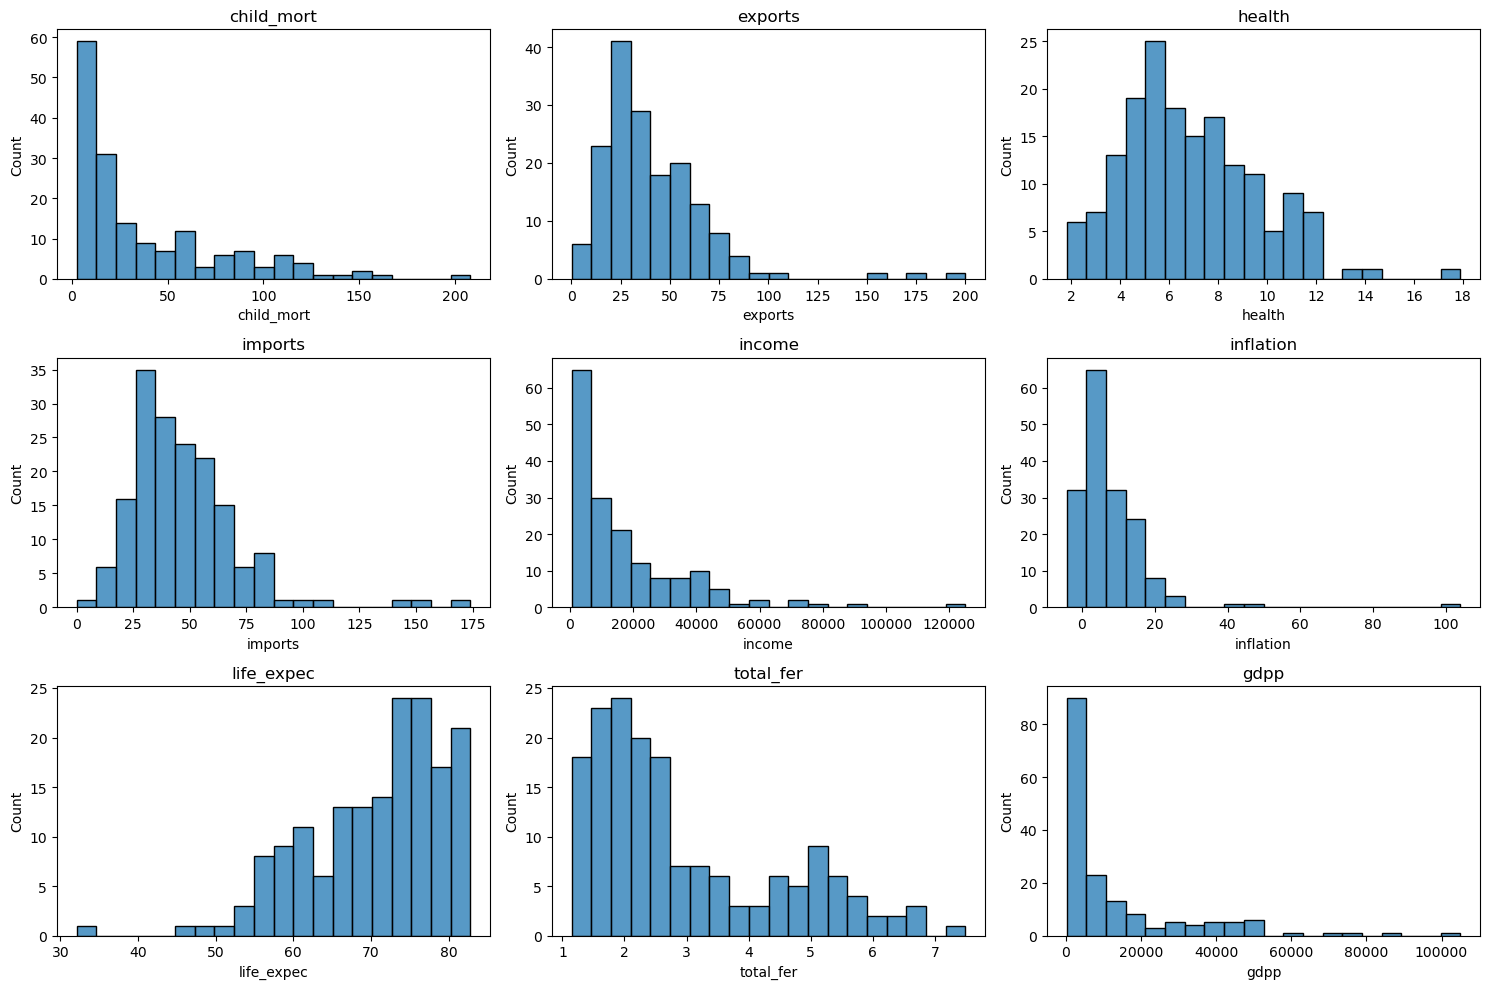

In [7]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,10))
fig=1
for col in num_cols:
    plt.subplot(3,3,fig)
    sns.histplot(x=df[col],bins=20)
    plt.title(col)
    plt.tight_layout()
    fig+=1

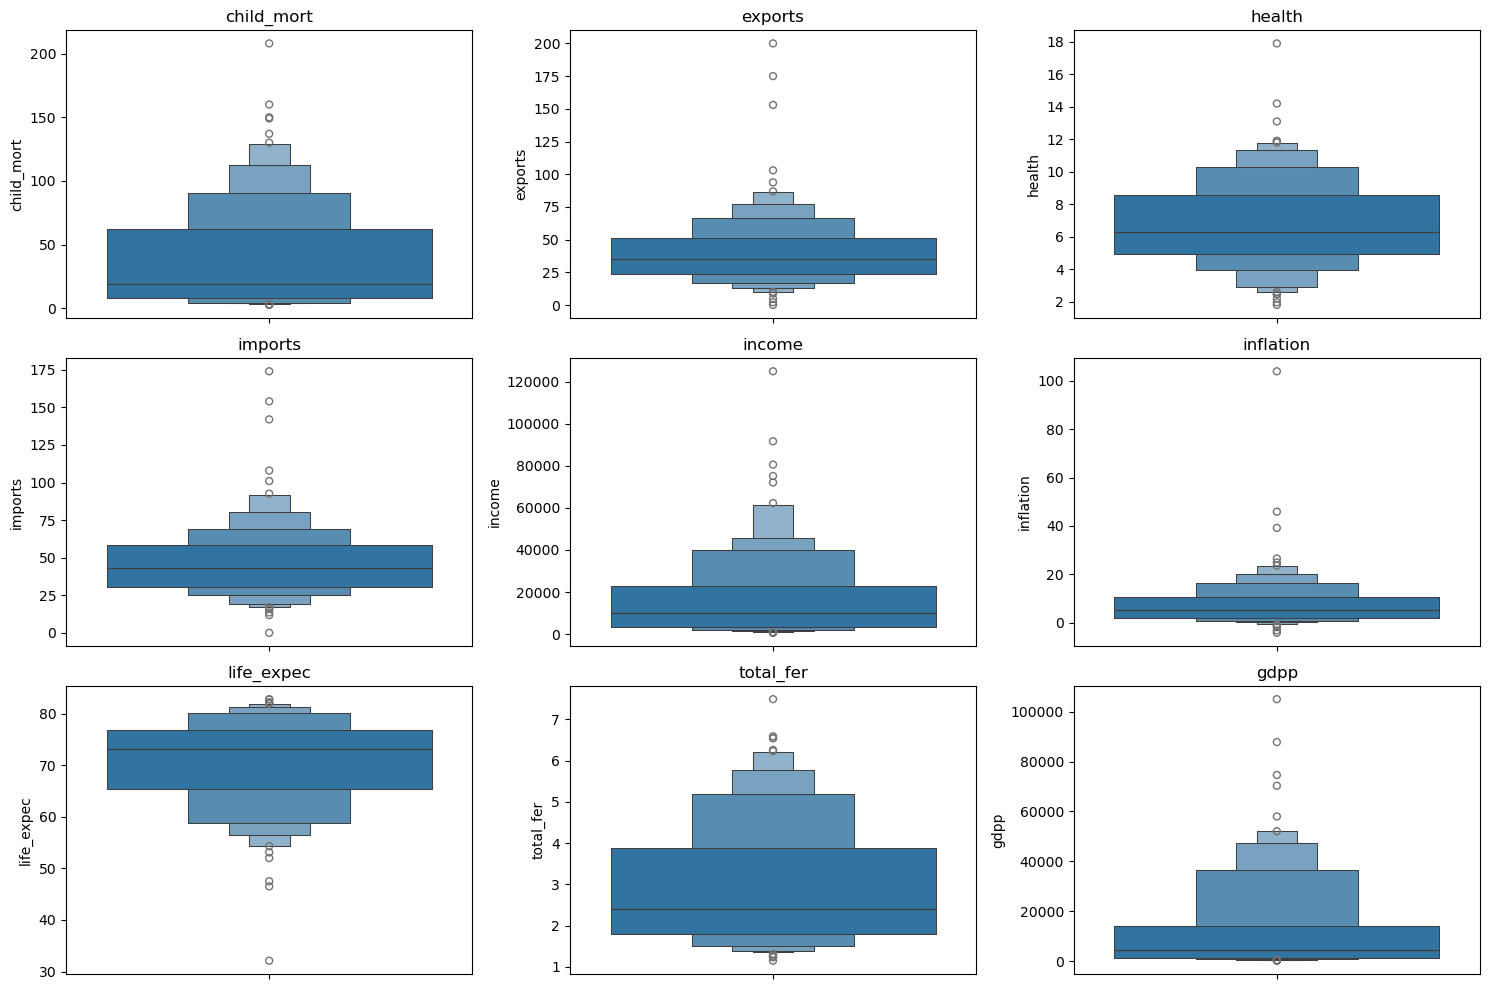

In [8]:
plt.figure(figsize=(15,10))
fig=1
for col in num_cols:
    plt.subplot(3,3,fig)
    sns.boxenplot(y=df[col])
    plt.title(col)
    plt.tight_layout()
    fig+=1

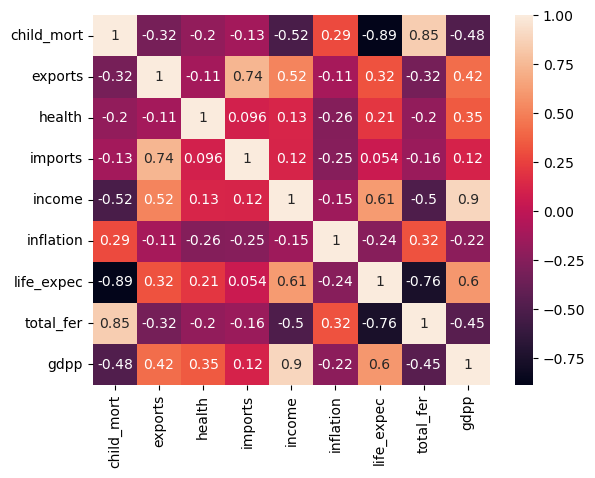

In [9]:
corr = df[num_cols].corr()
sns.heatmap(corr,annot=True);

Dari grafik **heatmap** diatas fitur **life_expec** dan **income** memiliki **korelasi** yang besar dengan fitur **gdpp**

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

**Memisahkan Fitur "country" dan Standarisasi Fitur**

In [10]:
df_transformed = df.copy()
country_names = df['country']

scaler = StandardScaler()
df_transformed[num_cols] = scaler.fit_transform(df_transformed[num_cols])

df_transformed = df_transformed.drop(columns='country')
df_transformed

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
...,...,...,...,...,...,...,...,...,...
162,-0.225578,0.200917,-0.571711,0.240700,-0.738527,-0.489784,-0.852161,0.365754,-0.546913
163,-0.526514,-0.461363,-0.695862,-1.213499,-0.033542,3.616865,0.546361,-0.316678,0.029323
164,-0.372315,1.130305,0.008877,1.380030,-0.658404,0.409732,0.286958,-0.661206,-0.637754
165,0.448417,-0.406478,-0.597272,-0.517472,-0.658924,1.500916,-0.344633,1.140944,-0.637754


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

In [11]:
model = KMeans(random_state=42, n_init=10)

## **b. Evaluasi Model Clustering**

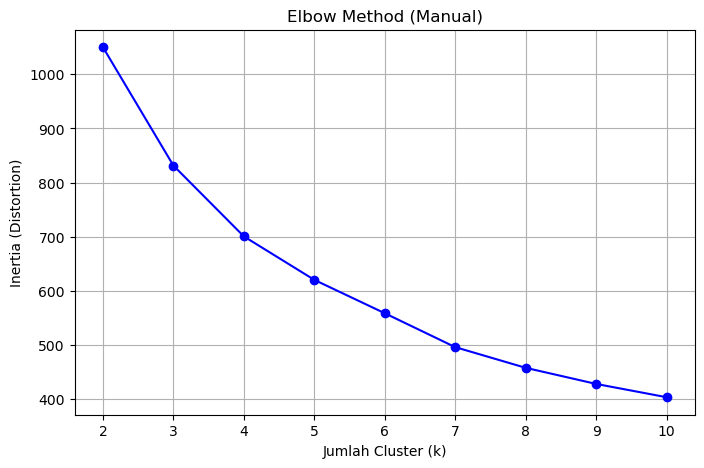

In [12]:
inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_transformed)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (Distortion)')
plt.title('Elbow Method (Manual)')
plt.grid(True)
plt.show()

Dari hasil visualisasi **Elbow Method** di atas saya memilih 5 cluster karena setelah 5 cluster penurunannya sudah mulai melandai

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
silhouette_score(df_transformed, kmeans.fit_predict(df_transformed))

0.30088229124112015

**Silhoutte score** yang saya dapatkan cukup moderat yang berarti ada tumpang tindih (overlap) antar cluster. Beberapa negara mungkin punya karakteristik yang mirip sehingga model agak "bingung" memasukkannya ke cluster mana.

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

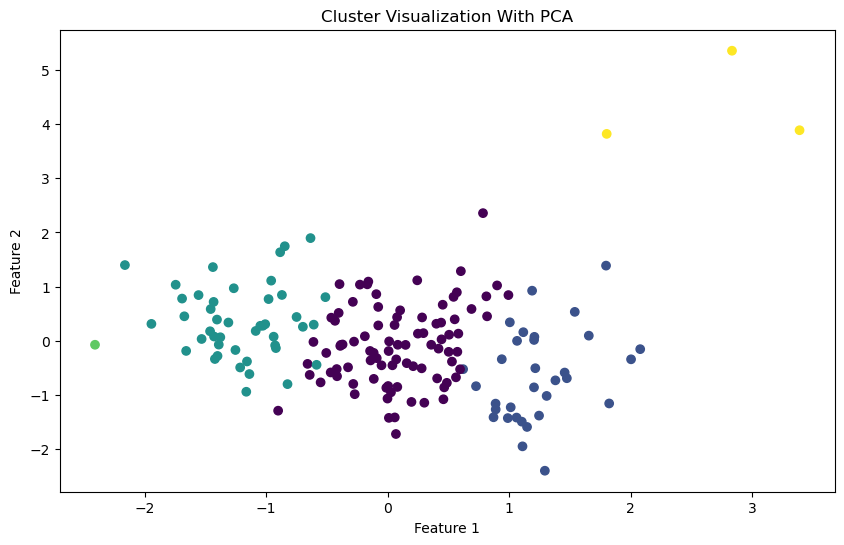

In [14]:
pca = PCA(n_components=2,whiten=True)
data_pca = pca.fit_transform(df_transformed)

plt.figure(figsize=(10, 6))
plt.scatter(x=data_pca[:, 0], y=data_pca[:, 1],c=kmeans.labels_,cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Cluster Visualization With PCA")
plt.show()

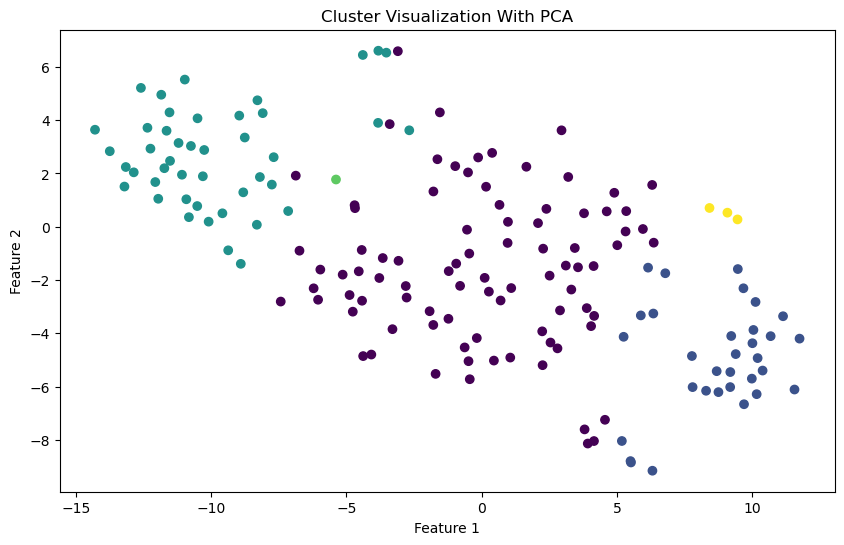

In [15]:
tsne = TSNE(n_components=2)
data_tsne = tsne.fit_transform(df_transformed)

plt.figure(figsize=(10, 6))
plt.scatter(x=data_tsne[:, 0], y=data_tsne[:, 1],c=kmeans.labels_,cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Cluster Visualization With PCA")
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [16]:
df_transformed[num_cols] = scaler.inverse_transform(df_transformed[num_cols])
df_transformed.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610.0,9.44,56.2,5.82,553.0
1,16.6,28.0,6.55,48.6,9930.0,4.49,76.3,1.65,4090.0
2,27.3,38.4,4.17,31.4,12900.0,16.10,76.5,2.89,4460.0
3,119.0,62.3,2.85,42.9,5900.0,22.40,60.1,6.16,3530.0
4,10.3,45.5,6.03,58.9,19100.0,1.44,76.8,2.13,12200.0


In [17]:
df = df_transformed
df['cluster'] = kmeans.labels_
df['country'] = country_names
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,country
0,90.2,10.0,7.58,44.9,1610.0,9.44,56.2,5.82,553.0,2,Afghanistan
1,16.6,28.0,6.55,48.6,9930.0,4.49,76.3,1.65,4090.0,0,Albania
2,27.3,38.4,4.17,31.4,12900.0,16.10,76.5,2.89,4460.0,0,Algeria
3,119.0,62.3,2.85,42.9,5900.0,22.40,60.1,6.16,3530.0,2,Angola
4,10.3,45.5,6.03,58.9,19100.0,1.44,76.8,2.13,12200.0,0,Antigua and Barbuda


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [18]:
top_features = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
summary_profile = df.groupby('cluster')[top_features].mean()

summary_profile['count'] = df['cluster'].value_counts()

summary_profile.sort_values(by='gdpp', ascending=False)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,count
cluster,,,,,,,,,,
4,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667,3
1,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000,32
0,22.219540,41.083782,6.246667,47.795010,12678.965517,7.727747,72.625287,2.333333,6494.390805,87
3,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000,1
2,94.313636,28.677500,6.329091,42.872727,3503.250000,9.895568,59.022727,5.047727,1753.909091,44


In [19]:
df[df['cluster']==0].sort_values(by='gdpp',ascending=False).head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,country
11,8.6,69.5,4.97,50.9,41100.0,7.440,76.0,2.16,20700.0,0,Bahrain
115,11.7,65.7,2.77,41.2,45300.0,15.600,76.1,2.90,19300.0,0,Oman
128,15.7,49.6,4.29,33.0,45400.0,17.200,75.1,2.96,19300.0,0,Saudi Arabia
134,7.0,76.3,8.79,77.8,25200.0,0.485,75.5,1.43,16600.0,0,Slovak Republic
13,14.2,39.5,7.97,48.7,15300.0,0.321,76.7,1.78,16000.0,0,Barbados


In [20]:
df[df['cluster']==1].sort_values(by='gdpp',ascending=False).head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,country
114,3.2,39.7,9.48,28.5,62300.0,5.950,81.0,1.95,87800.0,1,Norway
145,4.5,64.0,11.50,53.3,55500.0,0.317,82.2,1.52,74600.0,1,Switzerland
123,9.0,62.3,1.81,23.8,125000.0,6.980,79.5,2.07,70300.0,1,Qatar
44,4.1,50.5,11.40,43.6,44000.0,3.220,79.5,1.87,58000.0,1,Denmark
144,3.0,46.2,9.63,40.7,42900.0,0.991,81.5,1.98,52100.0,1,Sweden


In [21]:
df[df['cluster']==2].sort_values(by='gdpp',ascending=False).head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,country
49,111.0,85.8,4.48,58.9,33700.0,24.90,60.9,5.21,17100.0,2,Equatorial Guinea
55,63.7,57.7,3.50,18.9,15400.0,16.60,62.9,4.08,8750.0,2,Gabon
137,53.7,28.6,8.94,27.4,12000.0,6.35,54.3,2.59,7280.0,2,South Africa
108,56.0,47.8,6.78,60.7,8460.0,3.56,58.6,3.60,5190.0,2,Namibia
149,62.6,2.2,9.12,27.8,1850.0,26.50,71.1,6.23,3600.0,2,Timor-Leste


In [22]:
df[df['cluster']==3].sort_values(by='gdpp',ascending=False).head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,country
113,130.0,25.3,5.07,17.4,5150.0,104.0,60.5,5.84,2330.0,3,Nigeria


In [23]:
df[df['cluster']==4].sort_values(by='gdpp',ascending=False).head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,country
91,2.8,175.0,7.77,142.0,91700.0,3.620,81.3,1.63,105000.0,4,Luxembourg
133,2.8,200.0,3.96,174.0,72100.0,-0.046,82.7,1.15,46600.0,4,Singapore
98,6.8,153.0,8.65,154.0,28300.0,3.830,80.3,1.36,21100.0,4,Malta


Tulis hasil interpretasinya di sini.
1. Cluster 0: Negara transisi menuju maju
2. Cluster 1: Negara maju 
3. Cluster 2: Negara berkembang dengan tantangan struktural
4. Cluster 3: Negara dengan kondisi ekstrem
5. Cluster 4: Negara super maju

# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 0 – Negara menuju Maju

- **Rata-rata Income per Kapita**: 12,679
- **Rata-rata GDP per Kapita**: 6,494
- **Rata-rata Angka Kematian Bayi**: 22.22
- **Rata-rata Harapan Hidup**: 72.63 tahun
- **Rata-rata Total Fertility Rate**: 2.33

**Analisis**:
Cluster ini mencakup negara-negara dengan tingkat pembangunan menengah. Pendapatan dan GDP per kapita sudah relatif baik, disertai dengan harapan hidup yang cukup tinggi dan angka kematian bayi yang mulai menurun. Negara-negara dalam cluster ini umumnya berada pada fase transisi pembangunan, di mana kualitas hidup meningkat namun masih menghadapi tantangan seperti inflasi, ketimpangan sosial, dan efisiensi layanan publik.

## Cluster 1 – Negara Maju

- **Rata-rata Income per Kapita**: 44,022
- **Rata-rata GDP per Kapita**: 42,119
- **Rata-rata Angka Kematian Bayi**: 5.18
- **Rata-rata Harapan Hidup**: 80.08 tahun
- **Rata-rata Total Fertility Rate**: 1.79

**Analisis**:
Cluster ini merepresentasikan negara-negara dengan tingkat pembangunan sangat tinggi. Pendapatan dan GDP per kapita besar, angka kematian bayi sangat rendah, serta harapan hidup tinggi. Negara dalam cluster ini memiliki sistem kesehatan dan ekonomi yang matang, stabilitas makroekonomi yang baik, serta kualitas hidup yang tinggi. Tantangan utama bukan lagi pertumbuhan, melainkan penuaan penduduk dan keberlanjutan sistem sosial.

## Cluster 2 – Negara Berkembang dengan Tantangan Struktural

- **Rata-rata Income per Kapita**: 3,503
- **Rata-rata GDP per Kapita**: 1,754
- **Rata-rata Angka Kematian Bayi**: 94.31
- **Rata-rata Harapan Hidup**: 59.02 tahun
- **Rata-rata Total Fertility Rate**: 5.05

**Analisis**:
Cluster ini mencakup negara-negara dengan tingkat kesejahteraan rendah dan tantangan pembangunan yang serius. Pendapatan dan GDP per kapita rendah, disertai dengan angka kematian bayi yang tinggi serta tingkat fertilitas yang besar. Kondisi ini mencerminkan keterbatasan akses terhadap layanan kesehatan, pendidikan, dan infrastruktur dasar, serta tekanan demografis yang tinggi terhadap perekonomian.

## Cluster 3 – Negara dengan Kondisi Ekstrem

- **Rata-rata Income per Kapita**: 5,150
- **Rata-rata GDP per Kapita**: 2,330
- **Rata-rata Angka Kematian Bayi**: 130.00
- **Rata-rata Harapan Hidup**: 60.50 tahun
- **Rata-rata Inflasi**: 104.00

**Analisis**:
Cluster ini menggambarkan negara-negara dengan kondisi ekonomi dan sosial yang sangat tidak stabil. Inflasi yang sangat tinggi, angka kematian bayi ekstrem, serta rendahnya aktivitas perdagangan menunjukkan adanya krisis struktural. Negara-negara dalam cluster ini umumnya menghadapi permasalahan serius seperti konflik, ketidakstabilan politik, atau kegagalan kebijakan ekonomi.

## Cluster 4 – Negara Super Kaya

- **Rata-rata Income per Kapita**: 64,033
- **Rata-rata GDP per Kapita**: 57,567
- **Rata-rata Angka Kematian Bayi**: 4.13
- **Rata-rata Harapan Hidup**: 81.43 tahun
- **Rata-rata Ekspor**: 176.00

**Analisis**:
Cluster ini mencakup negara-negara dengan tingkat pendapatan tertinggi dan keterbukaan perdagangan yang sangat besar. Harapan hidup sangat tinggi dan angka kematian bayi sangat rendah menunjukkan kualitas hidup yang sangat baik. Perekonomian negara dalam cluster ini sangat bergantung pada perdagangan internasional, keuangan global, atau sumber daya strategis, sehingga sangat sensitif terhadap dinamika ekonomi global.

# **7. Mengeksport Data**

_Export data dengan label cluster jika kedepannya data ini akan digunakan untuk membangun model **klasifikasi**_

In [24]:
df.to_csv('clustered_country_data.csv',index=False)